# Chronos-2 — Panama Electric Load Forecasting (S1–S4)
**Darekar, Kim, Saxena | University of Trier | RCS SS2026**



- **S1** — Univariate zero-shot baseline
- **S2** — Covariate-informed forecasting (Panama City weather + calendar)
- **S3a** — Cross-city learning (Tocumen / Santiago / David temperatures, already in the raw dataset)
- **S3b** — STL decomposition cross-learning (trend + seasonal(24h) + residual, forecast jointly)
- **S4** — Ensemble-based forecasting (10 weather realizations → averaged)


In [4]:
import sys, subprocess
result = subprocess.run([sys.executable, "-m", "pip", "install", "openmeteo_requests", "requests_cache", "retry_requests"], capture_output=True, text=True)
print(result.stdout[-1500:])
print(result.stderr[-1500:])

/python3.11/site-packages (from cattrs>=22.2->requests_cache) (4.15.0)




In [5]:
import sys
print("Kernel Python:", sys.executable)

import subprocess
result = subprocess.run([sys.executable, "-m", "pip", "install", "entsoe-py"], capture_output=True, text=True)
print(result.stdout[-1500:])
print(result.stderr[-1500:])

Kernel Python: /opt/homebrew/opt/python@3.11/bin/python3.11
) (2026.2)




In [6]:
import sys, subprocess
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-r", "requirements.txt"],
    capture_output=True, text=True,
    cwd="/Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research"
)
print(result.stdout[-3000:])
print("--- STDERR ---")
print(result.stderr[-2000:])



--- STDERR ---



In [7]:
# Standard library and third-party imports
import sys, os
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from chronos import Chronos2Pipeline
from transformers.utils.logging import disable_progress_bar
from IPython.display import Image, display
from statsmodels.tsa.seasonal import STL

sys.path.insert(0, os.path.join(os.getcwd(), "src"))
warnings.filterwarnings("ignore")

from config          import RESULTS_DIR, DATA_DIR, MODEL_ID, TARGET_COLUMN, TIMESTAMP_COLUMN, WEATHER_VARS, N_DAYS
from data_loader     import (pan_load, pan_preprocessing, fetch_weather, add_calendar, apply_semantic_pca,
                             merge_context_with_covariates, extract_prediction_timeframe, merge_location_weather,
                             PAN_START_DATE)
from metrics         import calculate_metrics, compute_summary_statistics, calculate_weather_correlations
from tests           import diebold_mariano_test
from plots           import plot_metrics_boxplots, plot_distribution, plot_time_series, plot_correlation
from scenarios       import s1_predict, s2_predict, s1_evaluation

print("All imports OK")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {'cuda' if torch.cuda.is_available() else 'cpu'}")

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK
PyTorch  : 2.12.0
Device   : cpu


## 1 — Load and Preprocess Panama Data


--- Panama (PAN) Electricity Load Dataset ---
                 datetime  nat_demand    T2M_toc  QV2M_toc   TQL_toc  \
0     2015-01-03 01:00:00    970.3450  25.865259  0.018576  0.016174   
1     2015-01-03 02:00:00    912.1755  25.899255  0.018653  0.016418   
2     2015-01-03 03:00:00    900.2688  25.937280  0.018768  0.015480   
3     2015-01-03 04:00:00    889.9538  25.957544  0.018890  0.016273   
4     2015-01-03 05:00:00    893.6865  25.973840  0.018981  0.017281   
...                   ...         ...        ...       ...       ...   
48043 2020-06-26 20:00:00   1128.5592  27.246545  0.020303  0.055511   
48044 2020-06-26 21:00:00   1112.7488  27.099573  0.020395  0.053848   
48045 2020-06-26 22:00:00   1081.5680  26.971155  0.020448  0.057251   
48046 2020-06-26 23:00:00   1041.6240  26.867487  0.020464  0.064178   
48047 2020-06-27 00:00:00   1013.5683  26.750330  0.020441  0.063965   

         W2M_toc    T2M_san  QV2M_san   TQL_san    W2M_san    T2M_dav  \
0      21.85054

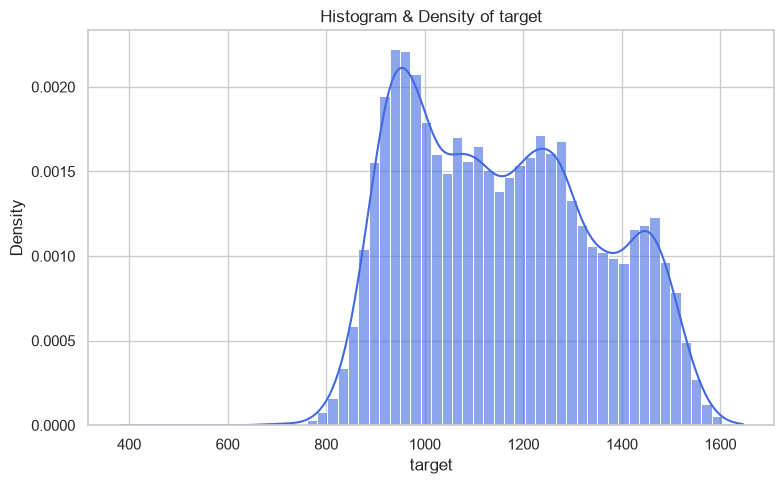

In [8]:
# LOAD & PREPROCESS DATA
pan_loaded_data = pan_load()  # Uses default continuous_dataset.csv
print("\n--- Panama (PAN) Electricity Load Dataset ---")
print(pan_loaded_data)
pan_preprocessing(pan_loaded_data)

pan_context_df = pd.read_csv(DATA_DIR / "processed" / "pan_context_df.csv")
print("\n--- Target Variable Summary Statistics ---")
deduplicated_pan_context_df = pan_context_df.drop_duplicates(subset=[TIMESTAMP_COLUMN])
print(compute_summary_statistics(deduplicated_pan_context_df, columns=[TARGET_COLUMN]))
plot_distribution(deduplicated_pan_context_df, columns=[TARGET_COLUMN])

## 2 — Load Chronos-2
Downloads ~700 MB on first run, cached locally after that.

In [9]:
disable_progress_bar()

pipeline = Chronos2Pipeline.from_pretrained(
    MODEL_ID,                     # "amazon/chronos-2"  (set in config.py)
    device_map = "cuda" if torch.cuda.is_available() else "cpu",
    torch_dtype = torch.bfloat16, # use float32 if you get dtype errors on CPU
)

print(f"Loaded {MODEL_ID}")

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


Loaded amazon/chronos-2


---
## S1 — Univariate Baseline (zero-shot)
Chronos-2 on raw demand only. Reference point for all adaptations below.

Predictions successfully created and saved to '/Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_pred.csv'.
Metrics successfully created and saved to '/Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_res.csv'.
--- Panama (PAN) Electricity Load Forecasting Accuracy Metrics (RMSE and MAPE): Summary Statistics ---
               rmse         mape
count   1095.000000  1095.000000
mean      51.237708     3.547693
median    38.102233     2.637731
var     1756.547068     8.545565
min       10.481519     0.681504
q1        26.282640     1.850816
q3        56.817050     4.038545
max      299.072414    23.481573

--- Panama (PAN) Electricity Load Time Series Forecasting Plot ---


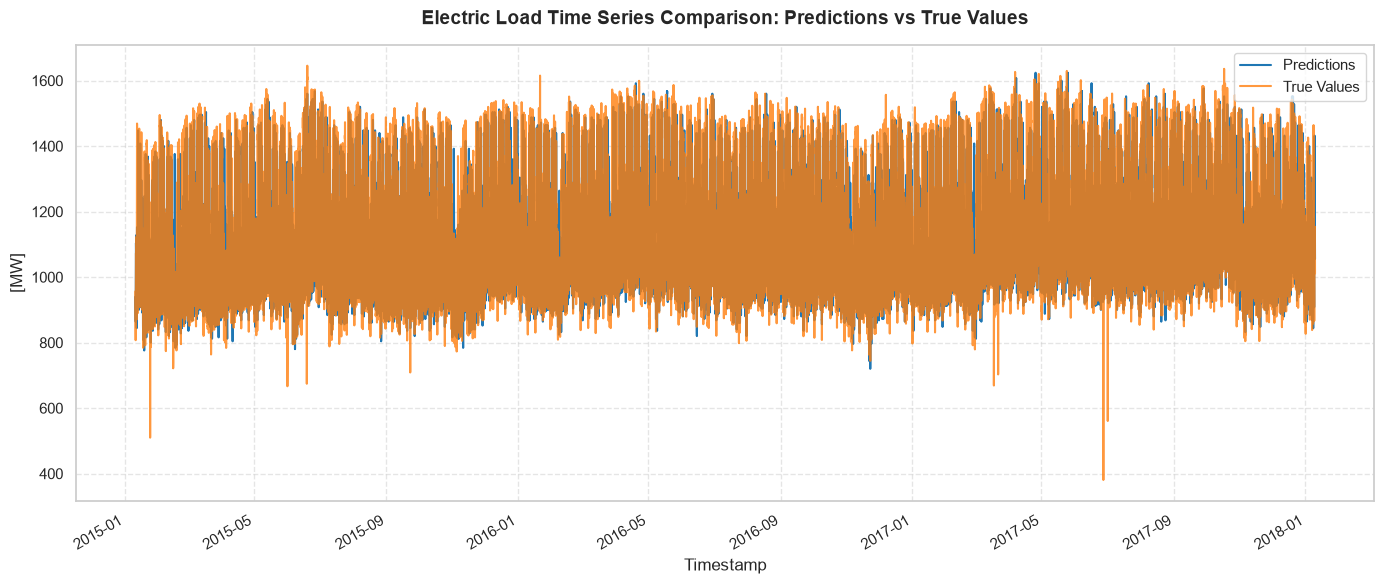

Plot successfully created and saved to '/Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_time_series.png'.


In [10]:
pan_context_df = pd.read_csv(DATA_DIR / "processed" / "pan_context_df.csv")
pan_ground_truth = np.load(DATA_DIR / "processed" / "pan_horizon_true.npy")

pan_pred = s1_predict(pipeline, pan_context_df, save_path = RESULTS_DIR / "pan_pred.csv")
pan_res = s1_evaluation(pan_pred, pan_ground_truth, save_path = RESULTS_DIR / "pan_res.csv")

print("--- Panama (PAN) Electricity Load Forecasting Accuracy Metrics (RMSE and MAPE): Summary Statistics ---")
print(compute_summary_statistics(pan_res, columns=['rmse', 'mape']))

print("\n--- Panama (PAN) Electricity Load Time Series Forecasting Plot ---")
plot_time_series(pan_pred, pan_ground_truth, RESULTS_DIR / "pan_time_series.png")

---
## S2 — Covariate-Informed Forecasting
Weather (Panama City proxy, PCA-reduced) + calendar features via `predict_df(future_df=...)`.

### 2.1 Build weather covariates

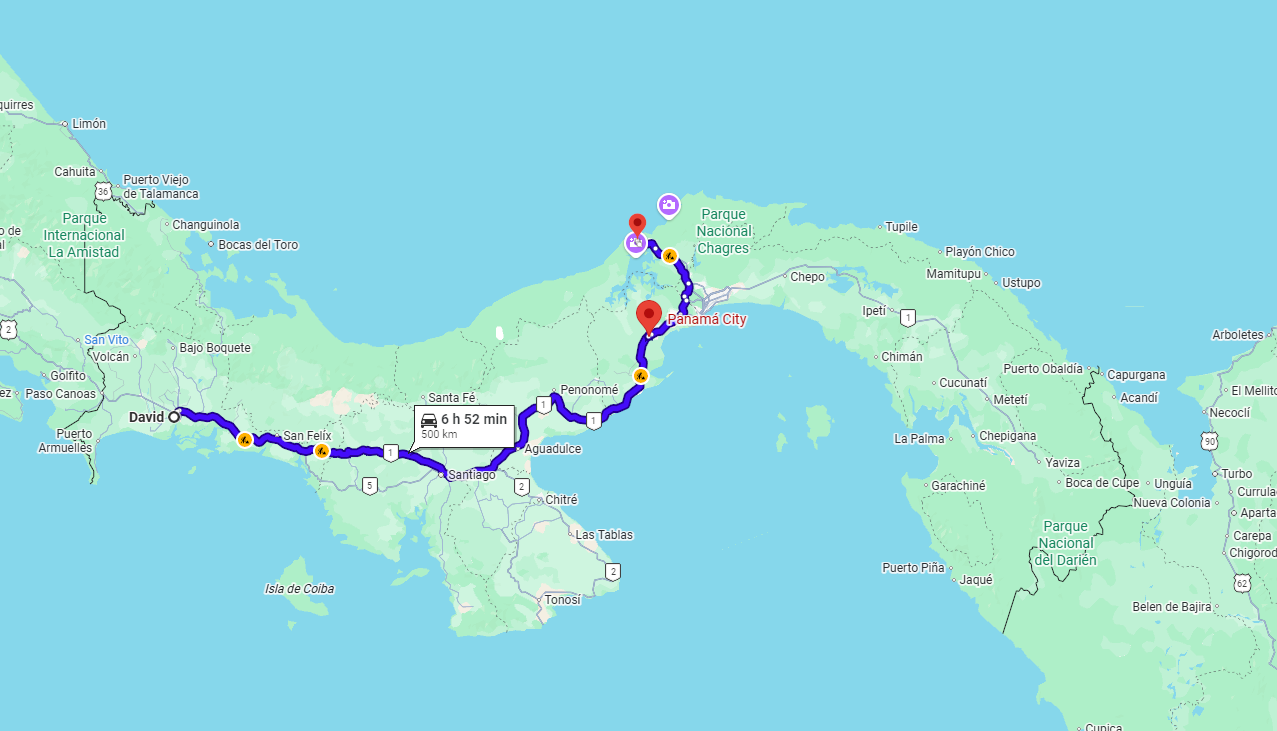

In [11]:
display(Image(DATA_DIR / "Images/Panama_Map.png"))

Approximately 47% of Panama's population resides in the Panama City metropolitan area. Weather
observations from Panama City alone are used as a proxy for national weather conditions, validated against
David and Colón below.

In [12]:
# Fetch weather data for Panama City, David, and Colón
pan_city_weather = fetch_weather(
    start_date = (pd.to_datetime(PAN_START_DATE) - pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
    end_date = (pd.to_datetime(PAN_START_DATE) + pd.Timedelta(days=N_DAYS + 7 - 1)).strftime('%Y-%m-%d'),
    latitude = 8.9936, longitude = -79.5197, offset_hours = -5)

pan_dav_weather = fetch_weather(
    start_date = (pd.to_datetime(PAN_START_DATE) - pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
    end_date = (pd.to_datetime(PAN_START_DATE) + pd.Timedelta(days=N_DAYS + 7 - 1)).strftime('%Y-%m-%d'),
    latitude = 8.4273, longitude = -82.4309, offset_hours = -5)

pan_col_weather = fetch_weather(
    start_date = (pd.to_datetime(PAN_START_DATE) - pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
    end_date = (pd.to_datetime(PAN_START_DATE) + pd.Timedelta(days=N_DAYS + 7 - 1)).strftime('%Y-%m-%d'),
    latitude = 9.3603, longitude = -79.9002, offset_hours = -5)

pan_weather = merge_location_weather(pan_city_weather, pan_dav_weather, pan_col_weather, ('_city', '_dav', '_col'))
pan_weather.to_csv(DATA_DIR / "processed" / "pan_weather.csv", index=False)
print(f"Shape of merged Panama weather data: {pan_weather.shape}")

Shape of merged Panama weather data: (26472, 43)


--- Weather Variable Correlations Across Panamanian Cities ---
                      variable  Panama_City-David  Panama_City-Colon  \
0               temperature_2m           0.889952           0.851773   
1                 dew_point_2m           0.745106           0.871352   
2                precipitation           0.172186           0.369674   
3                 pressure_msl           0.888320           0.978268   
4              cloud_cover_low           0.221878           0.491954   
5              cloud_cover_mid           0.363929           0.686410   
6             cloud_cover_high           0.704598           0.923174   
7               wind_speed_10m           0.390236           0.637790   
8              wind_speed_100m           0.445851           0.716037   
9               wind_gusts_10m           0.591620           0.757468   
10   soil_temperature_0_to_7cm           0.914346           0.874638   
11  soil_temperature_7_to_28cm           0.889993           0.739703   
1

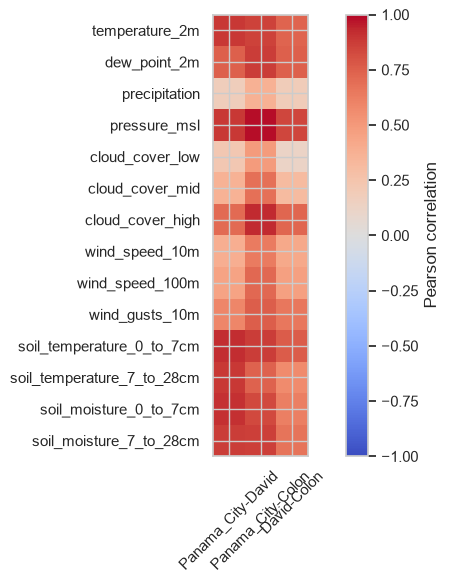

In [13]:
pan_weather_corr = calculate_weather_correlations(pan_weather, suffixes=('_city', '_dav', '_col'), labels=('Panama_City', 'David', 'Colon'))
print("--- Weather Variable Correlations Across Panamanian Cities ---")
print(pan_weather_corr)
plot_correlation(pan_weather_corr, save_path = RESULTS_DIR / "pan_weather_corr.png")

### 2.2 Predict and evaluate

In [14]:
# Panama City weather selected as the primary covariate source (per correlation analysis above).
pan_weather_single = pan_weather[['date'] + [col for col in pan_weather.columns if col.endswith('_city')]]
pan_weather_single.columns = [col.replace('_city', '') if col.endswith('_city') else col for col in pan_weather_single.columns]
pan_weather_reduced = apply_semantic_pca(pan_weather_single)

pan_covariates_df = add_calendar(pan_weather_reduced, country_code='PA')
# NOTE: which PCA covariates to drop should be tuned empirically the same way it was for AUS/LAT.
pan_covariates_df = pan_covariates_df.drop(columns=["dow"])
pan_covariates_df.to_csv(DATA_DIR / "processed" / "pan_covariates_df.csv", index=False)
print(pan_covariates_df)

                timestamp  temp_pc1  atmosphere_pc1  wind_pc1  soil_moist_pc1  \
0     2015-01-02 19:00:00  0.823037       -1.749186  1.324416       -0.388651   
1     2015-01-02 20:00:00  0.415762       -1.626153  1.311010       -0.388651   
2     2015-01-02 21:00:00  0.093530       -1.730193  1.354169       -0.388651   
3     2015-01-02 22:00:00 -0.113068       -1.713381  1.303821       -0.388651   
4     2015-01-02 23:00:00 -0.297516       -1.564272  1.194947       -0.388651   
...                   ...       ...             ...       ...             ...   
26467 2018-01-09 14:00:00  0.068749       -0.002114  0.494171        0.116005   
26468 2018-01-09 15:00:00  0.362097       -0.042874  0.504123        0.095980   
26469 2018-01-09 16:00:00  0.114822        1.117157  0.925729        0.089148   
26470 2018-01-09 17:00:00 -0.352885        1.204104  0.630353        0.095745   
26471 2018-01-09 18:00:00 -0.753419        0.759413  1.736534        0.095745   

       weekend  holiday  
0

In [15]:
pan_prediction_timeframe = extract_prediction_timeframe(pan_context_df)

pan_cov_context_df = merge_context_with_covariates(pan_context_df, pan_covariates_df, save_name = "pan_cov_context_df.csv")
pan_future_df = merge_context_with_covariates(pan_prediction_timeframe, pan_covariates_df, save_name = "pan_future_df.csv")

# Diagnostic: check for NaNs before forcing dtypes, so we know if there's a real alignment issue
print("weekend NaNs in future_df:", pan_future_df["weekend"].isna().sum(), "/", len(pan_future_df))
print("holiday NaNs in future_df:", pan_future_df["holiday"].isna().sum(), "/", len(pan_future_df))

# Force matching dtypes between context and future — predict_df requires this
for col in ["weekend", "holiday"]:
    if col in pan_cov_context_df.columns:
        pan_cov_context_df[col] = pan_cov_context_df[col].fillna(0).astype("int64")
    if col in pan_future_df.columns:
        pan_future_df[col] = pan_future_df[col].fillna(0).astype("int64")

pan_cov_pred = s2_predict(pipeline, pan_cov_context_df, pan_future_df, save_path = RESULTS_DIR / "pan_cov_pred.csv")
pan_cov_res = s1_evaluation(pan_cov_pred, pan_ground_truth, save_path = RESULTS_DIR / "pan_cov_res.csv")

print("--- Panama (PAN) S2 Accuracy Metrics (RMSE and MAPE): Summary Statistics ---")
print(compute_summary_statistics(pan_cov_res, columns=['rmse', 'mape']))

print("\n--- Panama (PAN) Diebold-Mariano Test: S2 vs S1 ---")
display(diebold_mariano_test(pan_ground_truth, pan_cov_pred, pan_pred))

File successfully saved to: /Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/data/processed/pan_cov_context_df.csv
File successfully saved to: /Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/data/processed/pan_future_df.csv
weekend NaNs in future_df: 5 / 26280
holiday NaNs in future_df: 5 / 26280
Predictions successfully created and saved to '/Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_cov_pred.csv'.
Metrics successfully created and saved to '/Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_cov_res.csv'.
--- Panama (PAN) S2 Accuracy Metrics (RMSE and MAPE): Summary Statistics ---
               rmse         mape
count   1095.000000  1095.000000
mean      54.236375     3.750530
median    39.214289     2.782322
var     1958.006701     9.164265
min       10.018350     0.621588
q1        26.767273     1.887358
q3  

{'DM statistic': 3.50101,
 'p-value': 0.0004635052823334096,
 'mean_loss_difference': 517.55733,
 'winner': 'Model 2',
 'n_forecasts': 1095,
 'bandwidth': 6}

---
## S3a — Cross-City Learning
Feed per-city temperature series (Tocumen, Santiago, David) as covariates alongside national demand.

Unlike S2, these are the **raw MERRA-2 reanalysis temperatures already embedded in `continuous_dataset.csv`**
(`T2M_toc`, `T2M_san`, `T2M_dav`) — no external API call needed, and no PCA reduction, so Chronos-2's group
attention sees all three cities directly instead of a single compressed component.

In [17]:
# Pull the three raw per-city temperature series straight from the source dataset.
pan_raw = pan_load()
pan_raw = pan_raw.rename(columns={"datetime": "date"})
pan_raw["date"] = pd.to_datetime(pan_raw["date"])

pan_crosscity_weather = pan_raw[["date", "T2M_toc", "T2M_san", "T2M_dav"]].copy()
pan_crosscity_weather = pan_crosscity_weather.rename(columns={"date": "timestamp"})  # <-- add_calendar expects 'timestamp'

pan_crosscity_covariates_df = add_calendar(pan_crosscity_weather, country_code='PA')
pan_crosscity_covariates_df = pan_crosscity_covariates_df.drop(columns=["dow"])
pan_crosscity_covariates_df.to_csv(DATA_DIR / "processed" / "pan_crosscity_covariates_df.csv", index=False)
print(pan_crosscity_covariates_df)

                timestamp    T2M_toc    T2M_san    T2M_dav  weekend  holiday
0     2015-01-03 01:00:00  25.865259  23.482446  22.662134        1        0
1     2015-01-03 02:00:00  25.899255  23.399255  22.578943        1        0
2     2015-01-03 03:00:00  25.937280  23.343530  22.531030        1        0
3     2015-01-03 04:00:00  25.957544  23.238794  22.512231        1        0
4     2015-01-03 05:00:00  25.973840  23.075403  22.481653        1        0
...                   ...        ...        ...        ...      ...      ...
48043 2020-06-26 20:00:00  27.246545  25.715295  23.746545        0        0
48044 2020-06-26 21:00:00  27.099573  25.552698  23.693323        0        0
48045 2020-06-26 22:00:00  26.971155  25.393030  23.658655        0        0
48046 2020-06-26 23:00:00  26.867487  25.258112  23.601862        0        0
48047 2020-06-27 00:00:00  26.750330  25.125330  23.562830        1        0

[48048 rows x 6 columns]


In [18]:
pan_crosscity_context_df = merge_context_with_covariates(pan_context_df, pan_crosscity_covariates_df, save_name = "pan_crosscity_context_df.csv")
pan_crosscity_future_df = merge_context_with_covariates(pan_prediction_timeframe, pan_crosscity_covariates_df, save_name = "pan_crosscity_future_df.csv")

pan_crosscity_pred = s2_predict(pipeline, pan_crosscity_context_df, pan_crosscity_future_df, save_path = RESULTS_DIR / "pan_crosscity_pred.csv")
pan_crosscity_res = s1_evaluation(pan_crosscity_pred, pan_ground_truth, save_path = RESULTS_DIR / "pan_crosscity_res.csv")

print("--- Panama (PAN) S3a Accuracy Metrics (RMSE and MAPE): Summary Statistics ---")
print(compute_summary_statistics(pan_crosscity_res, columns=['rmse', 'mape']))

print("\n--- Panama (PAN) Diebold-Mariano Test: S3a (cross-city) vs S1 (baseline) ---")
display(diebold_mariano_test(pan_ground_truth, pan_crosscity_pred, pan_pred))

print("\n--- Panama (PAN) Diebold-Mariano Test: S3a (cross-city) vs S2 (single-city PCA) ---")
display(diebold_mariano_test(pan_ground_truth, pan_crosscity_pred, pan_cov_pred))

File successfully saved to: /Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/data/processed/pan_crosscity_context_df.csv
File successfully saved to: /Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/data/processed/pan_crosscity_future_df.csv
Predictions successfully created and saved to '/Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_crosscity_pred.csv'.
Metrics successfully created and saved to '/Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_crosscity_res.csv'.
--- Panama (PAN) S3a Accuracy Metrics (RMSE and MAPE): Summary Statistics ---
               rmse         mape
count   1095.000000  1095.000000
mean      52.065459     3.607790
median    38.527304     2.713136
var     1821.878437     8.650123
min        9.067561     0.644691
q1        26.414970     1.823324
q3        59.625299     4.203158
max      287.588

{'DM statistic': 1.10361,
 'p-value': 0.2697630113833971,
 'mean_loss_difference': 150.781,
 'winner': 'Model 2',
 'n_forecasts': 1095,
 'bandwidth': 6}


--- Panama (PAN) Diebold-Mariano Test: S3a (cross-city) vs S2 (single-city PCA) ---


{'DM statistic': -2.86293,
 'p-value': 0.004197380514211924,
 'mean_loss_difference': -366.77633,
 'winner': 'Model 1',
 'n_forecasts': 1095,
 'bandwidth': 6}

---
## S3b — STL Decomposition Cross-Learning
Decompose demand → trend + seasonal (24h) + residual, forecast all three **jointly as separate series**
so Chronos-2's group attention can share structure across them, then sum the three component forecasts
back into a single demand forecast.

**ASSUMPTION:** this relies on `s1_predict` batching every `id` present in the input dataframe into one
`pipeline.predict_df()` call (as your S1 run already does for AUS, which processes ~180k rows / many
`AUS_SA_day_N` ids in a single call). That gives the model the *opportunity* to attend across the three
components of the same window, but whether it explicitly groups them (vs. treating all ids as
independent) depends on your `scenarios.py` implementation — check for a `group`/`item_id` grouping
argument in your `s1_predict` and `Chronos2Pipeline.predict_df` before trusting the cross-learning
interpretation of these numbers.

                      date         trend      seasonal         resid
count                48048  48048.000000  48048.000000  48048.000000
mean   2017-09-30 00:30:00   1214.234101      0.000799    -31.366253
min    2015-01-03 01:00:00    911.108540  -1006.328883  -1355.311336
25%    2016-05-17 12:45:00   1174.042788   -177.144442    -19.151620
50%    2017-09-30 00:30:00   1216.442019     28.800447     -2.957489
75%    2019-02-12 12:15:00   1257.836543    158.290892      7.159975
max    2020-06-27 00:00:00   1467.225656    325.955471    328.229227
std                    NaN     70.121568    183.405879     87.392267


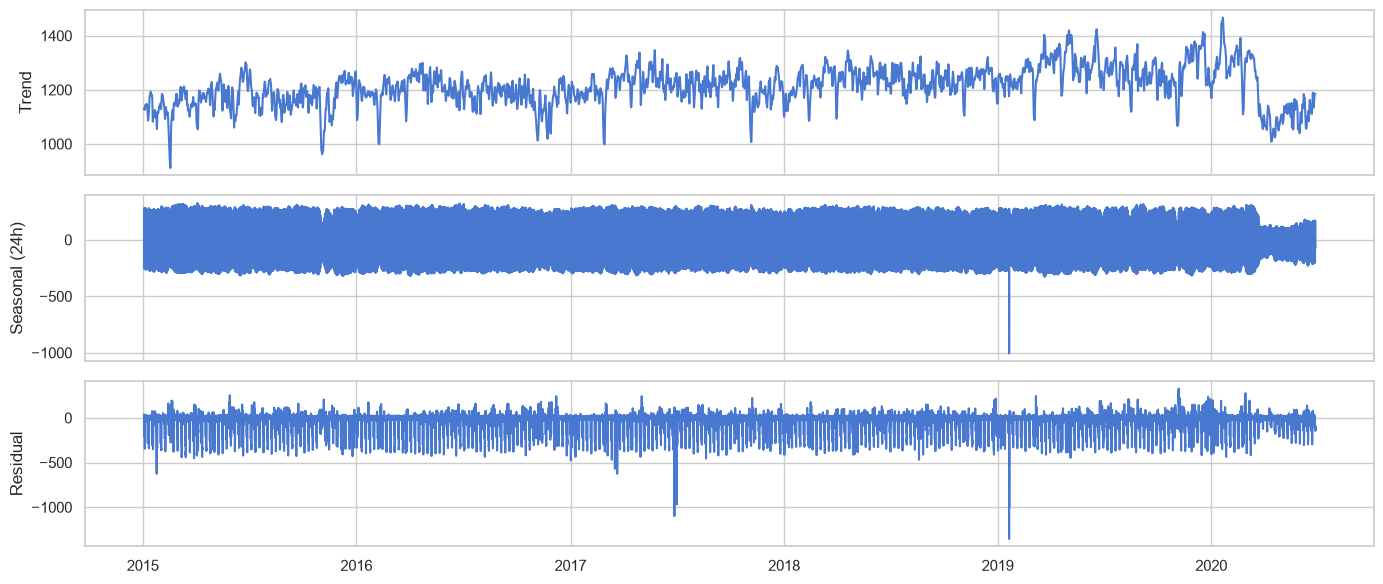

In [21]:
# STL decomposition of the full Panama demand series (24h seasonal period = daily cycle).
pan_demand_series = pan_raw.set_index("date")["nat_demand"].asfreq("h").interpolate()
stl_result = STL(pan_demand_series, period=24, robust=True).fit()

pan_stl_components = pd.DataFrame({
    "date": pan_demand_series.index,
    "trend": stl_result.trend.values,
    "seasonal": stl_result.seasonal.values,
    "resid": stl_result.resid.values,
})
print(pan_stl_components.describe())

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
axes[0].plot(pan_stl_components["date"], pan_stl_components["trend"]);    axes[0].set_ylabel("Trend")
axes[1].plot(pan_stl_components["date"], pan_stl_components["seasonal"]); axes[1].set_ylabel("Seasonal (24h)")
axes[2].plot(pan_stl_components["date"], pan_stl_components["resid"]);    axes[2].set_ylabel("Residual")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pan_stl_components.png")
plt.show()

In [26]:
# Build one long-format dataframe per component, re-using pan_context_df's window/id scaffold
# but swapping in the STL component values in place of the raw target.
def build_component_context(base_context_df, component_series_df, component_name):
    base_context_df = base_context_df.copy()
    base_context_df[TIMESTAMP_COLUMN] = pd.to_datetime(base_context_df[TIMESTAMP_COLUMN])
    component_series_df = component_series_df.copy()
    component_series_df["date"] = pd.to_datetime(component_series_df["date"])

    merged = base_context_df.merge(
        component_series_df[["date", component_name]],
        left_on=TIMESTAMP_COLUMN, right_on="date", how="left"
    )
    merged[TARGET_COLUMN] = merged[component_name]
    merged["id"] = merged["id"].astype(str) + f"__{component_name}"
    return merged.drop(columns=["date", component_name])
pan_trend_context    = build_component_context(pan_context_df, pan_stl_components, "trend")
pan_seasonal_context = build_component_context(pan_context_df, pan_stl_components, "seasonal")
pan_resid_context    = build_component_context(pan_context_df, pan_stl_components, "resid")

pan_stl_context_df = pd.concat([pan_trend_context, pan_seasonal_context, pan_resid_context], ignore_index=True)
pan_stl_context_df.to_csv(DATA_DIR / "processed" / "pan_stl_context_df.csv", index=False)
print(f"Combined STL context shape: {pan_stl_context_df.shape}")
print(pan_stl_context_df.head())

Combined STL context shape: (551880, 3)
            timestamp       target                id
0 2015-01-04 00:00:00  1125.813728  PAN_day_0__trend
1 2015-01-04 01:00:00  1125.822893  PAN_day_0__trend
2 2015-01-04 02:00:00  1125.993627  PAN_day_0__trend
3 2015-01-04 03:00:00  1126.320930  PAN_day_0__trend
4 2015-01-04 04:00:00  1126.783286  PAN_day_0__trend


In [ ]:
# Standard library and third-party imports
import sys, os
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from chronos import Chronos2Pipeline
from transformers.utils.logging import disable_progress_bar
from IPython.display import Image, display
from statsmodels.tsa.seasonal import STL

sys.path.insert(0, os.path.join(os.getcwd(), "src"))
warnings.filterwarnings("ignore")

from config          import RESULTS_DIR, DATA_DIR, MODEL_ID, TARGET_COLUMN, TIMESTAMP_COLUMN, WEATHER_VARS, N_DAYS
from data_loader     import (pan_load, pan_preprocessing, fetch_weather, add_calendar, apply_semantic_pca,
                             merge_context_with_covariates, extract_prediction_timeframe, merge_location_weather,
                             PAN_START_DATE)
from metrics         import calculate_metrics, compute_summary_statistics, calculate_weather_correlations
from tests           import diebold_mariano_test
from plots           import plot_metrics_boxplots, plot_distribution, plot_time_series, plot_correlation
from scenarios       import s1_predict, s2_predict, s1_evaluation

print("All imports OK")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {'cuda' if torch.cuda.is_available() else 'cpu'}")

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK
PyTorch  : 2.12.0
Device   : cpu


In [28]:
print(pan_stl_pred_raw.columns.tolist())

['id', 'timestamp', 'target_name', 'predictions', '0.1', '0.5', '0.9', 'base_id']


In [30]:
pan_stl_pred_raw["base_id"] = pan_stl_pred_raw["id"].str.replace(r"__(trend|seasonal|resid)$", "", regex=True)
pan_stl_pred = (
    pan_stl_pred_raw
    .groupby(["base_id", TIMESTAMP_COLUMN], as_index=False)["predictions"]
    .sum()
    .rename(columns={"base_id": "id"})
)
pan_stl_pred.to_csv(RESULTS_DIR / "pan_stl_pred.csv", index=False)

pan_stl_res = s1_evaluation(pan_stl_pred, pan_ground_truth, save_path = RESULTS_DIR / "pan_stl_res.csv")

print("--- Panama (PAN) S3b Accuracy Metrics (RMSE and MAPE): Summary Statistics ---")
print(compute_summary_statistics(pan_stl_res, columns=['rmse', 'mape']))

print("\n--- Panama (PAN) Diebold-Mariano Test: S3b (STL) vs S1 (baseline) ---")
display(diebold_mariano_test(pan_ground_truth, pan_stl_pred, pan_pred))

Metrics successfully created and saved to '/Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_stl_res.csv'.
--- Panama (PAN) S3b Accuracy Metrics (RMSE and MAPE): Summary Statistics ---
               rmse         mape
count   1095.000000  1095.000000
mean     113.595396     8.462641
median    89.292389     6.691586
var     5698.634143    36.962115
min       14.338544     0.961265
q1        52.967930     3.782005
q3       160.775798    11.499218
max      410.731281    39.171506

--- Panama (PAN) Diebold-Mariano Test: S3b (STL) vs S1 (baseline) ---


{'DM statistic': 19.88161,
 'p-value': 0.0,
 'mean_loss_difference': 14217.09841,
 'winner': 'Model 2',
 'n_forecasts': 1095,
 'bandwidth': 6}

---
## S4 — Ensemble-Based Forecasting
10 weather realisations → average (mirrors Copernicus ERA5 EDA).

**Proper version** requires ERA5 Ensemble of Data Assimilations via the Copernicus CDS API (`cdsapi`
package + free registration at https://cds.climate.copernicus.eu/). I've stubbed that path below.
Since I can't reach that API from this environment, there's also a **synthetic fallback** so you can
verify the averaging mechanics end-to-end before your CDS credentials are set up — swap
`USE_SYNTHETIC_ENSEMBLE = False` once real ERA5 EDA data is wired in.

In [31]:
USE_SYNTHETIC_ENSEMBLE = True   # set False once cdsapi / ERA5 EDA access is configured
N_ENSEMBLE_MEMBERS = 10

def fetch_era5_eda_ensemble(n_members=10):
    """ASSUMPTION / TODO: implement against Copernicus CDS ERA5 EDA (10 realizations, 3-hourly, 1x1deg).
    Requires: pip install cdsapi, and a ~/.cdsapirc with your API key.
    Should return a list of `n_members` weather DataFrames, each shaped like `pan_city_weather`
    (columns: date, temperature_2m, ...), one per ensemble realization, covering the same
    PAN_START_DATE .. PAN_START_DATE + N_DAYS + 7 window used elsewhere in this notebook.
    """
    raise NotImplementedError(
        "Wire this up to cdsapi + the Copernicus ERA5 EDA product once CDS credentials are available. "
        "See: https://cds.climate.copernicus.eu/"
    )

def synthetic_weather_ensemble(base_weather_df, n_members=10, temp_col="temperature_2m", noise_std_c=0.8):
    """Stand-in ensemble: perturbs the deterministic Panama City forecast with Gaussian noise on
    temperature only, roughly calibrated to typical short-range ERA5 EDA spread (~0.5-1.5C).
    NOT a substitute for real ensemble data — use only to test the S4 pipeline mechanics."""
    rng = np.random.default_rng(42)
    members = []
    for m in range(n_members):
        member_df = base_weather_df.copy()
        member_df[temp_col] = member_df[temp_col] + rng.normal(0, noise_std_c, size=len(member_df))
        members.append(member_df)
    return members

if USE_SYNTHETIC_ENSEMBLE:
    pan_weather_ensemble = synthetic_weather_ensemble(pan_weather_single, n_members=N_ENSEMBLE_MEMBERS)
    print(f"Generated {len(pan_weather_ensemble)} SYNTHETIC weather ensemble members (placeholder for ERA5 EDA).")
else:
    pan_weather_ensemble = fetch_era5_eda_ensemble(n_members=N_ENSEMBLE_MEMBERS)
    print(f"Fetched {len(pan_weather_ensemble)} ERA5 EDA weather ensemble members.")

Generated 10 SYNTHETIC weather ensemble members (placeholder for ERA5 EDA).


In [33]:
# Run S2-style covariate forecasting once per ensemble member, then average the resulting predictions.
pan_ensemble_preds = []

for m, member_weather in enumerate(pan_weather_ensemble):
    member_reduced = apply_semantic_pca(member_weather)
    member_covariates_df = add_calendar(member_reduced, country_code='PA').drop(columns=["dow"])

    member_context_df = merge_context_with_covariates(pan_context_df, member_covariates_df, save_name = f"pan_ens{m}_context_df.csv")
    member_future_df = merge_context_with_covariates(pan_prediction_timeframe, member_covariates_df, save_name = f"pan_ens{m}_future_df.csv")

    # Force matching dtypes between context and future — predict_df is strict about this (same fix as S2)
    for col in ["weekend", "holiday"]:
        if col in member_context_df.columns:
            member_context_df[col] = member_context_df[col].fillna(0).astype("int64")
        if col in member_future_df.columns:
            member_future_df[col] = member_future_df[col].fillna(0).astype("int64")

    member_pred = s2_predict(pipeline, member_context_df, member_future_df, save_path = RESULTS_DIR / f"pan_ens{m}_pred.csv")
    pan_ensemble_preds.append(member_pred)
    print(f"Ensemble member {m+1}/{len(pan_weather_ensemble)} done.")

# Average across the 10 members (elementwise on the predictions column, aligned by id + timestamp).
pan_ens_pred = pan_ensemble_preds[0][["id", TIMESTAMP_COLUMN]].copy()
target_stack = np.stack([p["predictions"].values for p in pan_ensemble_preds], axis=0)
pan_ens_pred["predictions"] = target_stack.mean(axis=0)
pan_ens_pred.to_csv(RESULTS_DIR / "pan_ens_pred.csv", index=False)

pan_ens_res = s1_evaluation(pan_ens_pred, pan_ground_truth, save_path = RESULTS_DIR / "pan_ens_res.csv")

print("--- Panama (PAN) S4 Accuracy Metrics (RMSE and MAPE): Summary Statistics ---")
print(compute_summary_statistics(pan_ens_res, columns=['rmse', 'mape']))

print("\n--- Panama (PAN) Diebold-Mariano Test: S4 (ensemble) vs S1 (baseline) ---")
display(diebold_mariano_test(pan_ground_truth, pan_ens_pred, pan_pred))

File successfully saved to: /Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/data/processed/pan_ens0_context_df.csv
File successfully saved to: /Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/data/processed/pan_ens0_future_df.csv
Predictions successfully created and saved to '/Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_ens0_pred.csv'.
Ensemble member 1/10 done.
File successfully saved to: /Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/data/processed/pan_ens1_context_df.csv
File successfully saved to: /Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/data/processed/pan_ens1_future_df.csv
Predictions successfully created and saved to '/Users/darekar/Desktop/RCS/RCS_time_series_forecasting_electric_load/chronos_research/results/pan_ens1_pred.csv'.
Ensemble member 2/10 done.
File successfu

{'DM statistic': 3.17834,
 'p-value': 0.0014812049049814924,
 'mean_loss_difference': 471.36103,
 'winner': 'Model 2',
 'n_forecasts': 1095,
 'bandwidth': 6}

---
## Results Summary — Panama, All Scenarios
Addresses **RQ1.1** (do adaptations improve on the univariate baseline?) and **RQ1.2** (which
configuration performs best) for the Panama dataset.

--- Panama (PAN) — Summary Statistics by Scenario ---

S1_baseline:
               rmse         mape
count   1095.000000  1095.000000
mean      51.237708     3.547693
median    38.102233     2.637731
var     1756.547068     8.545565
min       10.481519     0.681504
q1        26.282640     1.850816
q3        56.817050     4.038545
max      299.072414    23.481573

S2_covariate:
               rmse         mape
count   1095.000000  1095.000000
mean      54.236375     3.750530
median    39.214289     2.782322
var     1958.006701     9.164265
min       10.018350     0.621588
q1        26.767273     1.887358
q3        63.368480     4.413379
max      284.181050    22.277332

S3a_crosscity:
               rmse         mape
count   1095.000000  1095.000000
mean      52.065459     3.607790
median    38.527304     2.713136
var     1821.878437     8.650123
min        9.067561     0.644691
q1        26.414970     1.823324
q3        59.625299     4.203158
max      287.588590    23.249800

S3b_stl:


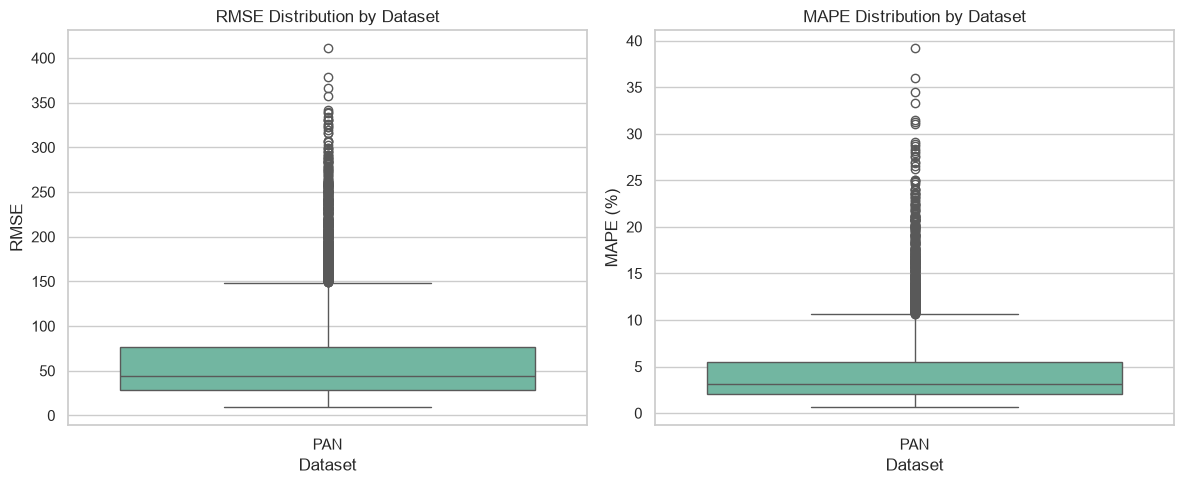

Box plots successfully created and saved.


In [34]:
pan_res_all = pd.concat([
    pan_res.assign(scenario="S1_baseline"),
    pan_cov_res.assign(scenario="S2_covariate"),
    pan_crosscity_res.assign(scenario="S3a_crosscity"),
    pan_stl_res.assign(scenario="S3b_stl"),
    pan_ens_res.assign(scenario="S4_ensemble"),
], ignore_index=True)

print("--- Panama (PAN) — Summary Statistics by Scenario ---")
for scenario, group in pan_res_all.groupby("scenario"):
    print(f"\n{scenario}:")
    print(compute_summary_statistics(group, columns=['rmse', 'mape']))

plot_metrics_boxplots(pan_res_all)